In [59]:
import torch
import torch.nn as nn
import torch.optim as optim

import pickle
import librosa
import numpy as np
from constants import *
from pathlib import Path
import IPython.display as ipd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
ney_feature_dirs = sorted(
    [f for f in Path(NEY_FEATURE_DIR).iterdir() if f.is_dir()])
gtr_feature_dirs = sorted(
    [f for f in Path(GTR_FEATURE_DIR).iterdir() if f.is_dir()])

In [3]:
x_train_dirs, x_test_dirs, y_train_dirs, y_test_dirs = train_test_split(
    gtr_feature_dirs, ney_feature_dirs, test_size=0.2, random_state=42)

print(len(x_train_dirs), len(x_test_dirs))

20 5


In [4]:
print(x_train_dirs[0], y_train_dirs[0])
print(x_test_dirs[0], y_test_dirs[0])

dataset/features/ac_gtr/09_Gtr_A_3 dataset/features/ney/09_Ney_A_3
dataset/features/ac_gtr/08_Gtr_G_S_3 dataset/features/ney/08_Ney_G_S_3


In [36]:
class FeatureDataset(Dataset):
    def __init__(self, x_dirs, y_dirs):
        self.x_dirs = x_dirs
        self.y_dirs = y_dirs
        self.x = None
        self.y = None
        self.file_paths_x = None
        self.file_paths_y = None

        # gtr files
        features_arr, file_paths_x = self._build_feature_data(self.x_dirs)
        self.x = features_arr
        self.file_paths_x = file_paths_x

        # ney files
        features_arr, file_paths_y = self._build_feature_data(self.y_dirs)
        self.y = features_arr
        self.file_paths_y = file_paths_y

    def _build_feature_data(self, dir_paths):
        features_arr = []
        paths_arr = []
        for dir_path in dir_paths:
            features, file_paths = self._get_features_in_dir(dir_path)
            features_arr.extend(features)
            paths_arr.extend(file_paths)

        features_arr = np.array(features_arr, dtype=np.float32)
        features_arr = np.expand_dims(features_arr, axis=1)
        paths_arr = np.array(paths_arr)
        return features_arr, paths_arr

    def _get_features_in_dir(self, dir_path):
        features = []
        file_paths = []
        sorted_files = sorted(list(Path(dir_path).iterdir()),
                              key=lambda x: int(x.stem.split("_")[1]))
        for f in sorted_files:
            with open(f, "rb") as handle:
                chunk = pickle.load(handle)
                signal = chunk["signal"]
                if len(signal) < WINDOW_SAMPLE_LEN:
                    signal = librosa.util.fix_length(signal, size=WINDOW_SAMPLE_LEN)
                features.append(signal)
                file_paths.append(str(f))
        return features, file_paths

    def __getitem__(self, index):
        return self.x[index], self.y[index], self.file_paths_x[index], self.file_paths_y[index]

    def __len__(self):
        return self.x.shape[0]

In [37]:
train_dataset = FeatureDataset(x_train_dirs, y_train_dirs)
test_dataset = FeatureDataset(x_test_dirs, y_test_dirs)

In [38]:
train_data_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True)

test_data_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False)

In [41]:
x, y, fp_x, fp_y = next(iter(test_data_loader))
print("Original shape:", x.shape)
# encoder
print("Encoder:")
x = nn.Conv1d(1, 16, 3, stride=1)(x)
print("1", x.shape)
x = nn.Conv1d(16, 32, 3, stride=2)(x)
print("2", x.shape)
x = nn.Conv1d(32, 64, 3, stride=2)(x)
print("3", x.shape)
x = nn.Conv1d(64, 128, 3, stride=1)(x)
print("4", x.shape)
# decoder
print("Decoder:")
x = nn.ConvTranspose1d(128, 64, 3, stride=1)(x)
print("5", x.shape)
x = nn.ConvTranspose1d(64, 32, 3, stride=2)(x)
print("6", x.shape)
x = nn.ConvTranspose1d(32, 16, 5, stride=2)(x)
print("7", x.shape)
x = nn.ConvTranspose1d(16, 1, 4, stride=1)(x)
print("8", x.shape)

Original shape: torch.Size([8, 1, 9600])
Encoder:
1 torch.Size([8, 16, 9598])
2 torch.Size([8, 32, 4798])
3 torch.Size([8, 64, 2398])
4 torch.Size([8, 128, 2396])
Decoder:
5 torch.Size([8, 64, 2398])
6 torch.Size([8, 32, 4797])
7 torch.Size([8, 16, 9597])
8 torch.Size([8, 1, 9600])


In [42]:
np.array(["a", "b"])

array(['a', 'b'], dtype='<U1')

In [44]:
class Gtr_2_Ney_AutoEncoder_Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1),
            nn.Tanh(),
            nn.Conv1d(16, 32, 3, stride=2),
            nn.Tanh(),
            nn.Conv1d(32, 64, 3, stride=2),
            nn.Tanh(),
            nn.Conv1d(64, 128, 3, stride=1)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=1),
            nn.Tanh(),
            nn.ConvTranspose1d(64, 32, 3, stride=2),
            nn.Tanh(),
            nn.ConvTranspose1d(32, 16, 5, stride=2),
            nn.Tanh(),
            nn.ConvTranspose1d(16, 1, 4, stride=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [45]:
gtr_2_ney_model_conv = Gtr_2_Ney_AutoEncoder_Conv()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model_conv.parameters(), lr=0.001)

for epoch in range(10):
    running_loss = 0.
    for gtr_features, ney_features, _, _ in train_data_loader:
        y_hat = gtr_2_ney_model_conv(gtr_features)
        loss = criterion(y_hat, ney_features)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch: {epoch + 1}, Loss: {running_loss:.4f}")

Epoch: 1, Loss: 3.7278
Epoch: 2, Loss: 3.6747
Epoch: 3, Loss: 3.6837
Epoch: 4, Loss: 3.6600
Epoch: 5, Loss: 3.6793
Epoch: 6, Loss: 3.6567
Epoch: 7, Loss: 3.6832
Epoch: 8, Loss: 3.6967
Epoch: 9, Loss: 3.7072
Epoch: 10, Loss: 3.6665


In [47]:
x, y, _, _ = next(iter(train_data_loader))
print("Original shape:", x.shape)
print("Encoder:")
x = nn.Linear(WINDOW_SAMPLE_LEN, WINDOW_SAMPLE_LEN // 2)(x)
print("1", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN // 4)(x)
print("2", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 8)(x)
print("3", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 16)(x)
print("4", x.shape)

print("Decoder:")
x = nn.Linear(WINDOW_SAMPLE_LEN // 16, WINDOW_SAMPLE_LEN // 8)(x)
print("5", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 4)(x)
print("6", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 2)(x)
print("7", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN)(x)
print("8", x.shape)

Original shape: torch.Size([8, 1, 9600])
Encoder:
1 torch.Size([8, 1, 4800])
2 torch.Size([8, 1, 2400])
3 torch.Size([8, 1, 1200])
4 torch.Size([8, 1, 600])
Decoder:
5 torch.Size([8, 1, 1200])
6 torch.Size([8, 1, 2400])
7 torch.Size([8, 1, 4800])
8 torch.Size([8, 1, 9600])


In [48]:
class Gtr_2_Ney_AutoEncoder_Dense(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(WINDOW_SAMPLE_LEN, WINDOW_SAMPLE_LEN // 2),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN // 4),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 8),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(WINDOW_SAMPLE_LEN // 16, WINDOW_SAMPLE_LEN // 8),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 4),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 2),
            nn.Tanh(),
            nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [51]:
gtr_2_ney_model_dense = Gtr_2_Ney_AutoEncoder_Dense()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model_dense.parameters(), lr=0.0005)

for epoch in range(10):
    running_loss = 0.
    for gtr_features, ney_features, _, _ in train_data_loader:
        y_hat = gtr_2_ney_model_dense(gtr_features)
        loss = criterion(y_hat, ney_features)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch: {epoch + 1}, Loss: {running_loss:.4f}")

Epoch: 1, Loss: 3.9447
Epoch: 2, Loss: 4.0575
Epoch: 3, Loss: 4.1120
Epoch: 4, Loss: 4.1152
Epoch: 5, Loss: 4.2505
Epoch: 6, Loss: 4.1414
Epoch: 7, Loss: 4.1246
Epoch: 8, Loss: 4.0042
Epoch: 9, Loss: 4.0005
Epoch: 10, Loss: 3.9834


In [58]:
def stitch_wave_chunks(waves):
    """ 
    Takes wave chunks as a list and stitches them with cross-fades.
    """
    stitched_wave = np.array([])
    fade_in = np.linspace(0, 1, FADE_SAMPLE_LEN)
    fade_out = np.linspace(1, 0, FADE_SAMPLE_LEN)

    for i, wave in enumerate(waves):
        if i > 0:
            # fade in wave chunks after the 1st one
            wave[:FADE_SAMPLE_LEN] *= fade_in
        # fade out all wave chunks
        wave[-FADE_SAMPLE_LEN:] *= fade_out

        if len(stitched_wave) > 0:
            stitched_wave[-FADE_SAMPLE_LEN:] += wave[:FADE_SAMPLE_LEN]
            stitched_wave = np.append(stitched_wave, wave[FADE_SAMPLE_LEN:])
        else:
            stitched_wave = np.append(stitched_wave, wave)

    return stitched_wave

In [65]:
x, y, x_paths, y_paths = next(iter(test_data_loader))
print(x_paths)
print(y_paths)
predicted_chunks = None
with torch.no_grad():
    predicted_chunks = gtr_2_ney_model_dense(x).numpy()

predicted_chunks = np.squeeze(predicted_chunks, axis=1)
target_chunks = np.squeeze(y.numpy(), axis=1)

stitched_wave_prediction = stitch_wave_chunks(predicted_chunks)
print("Prediction length:", len(stitched_wave_prediction))
stitched_wave_target = stitch_wave_chunks(target_chunks)
print("Target length:", len(stitched_wave_target))

('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_4', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_5', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_6', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_7')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3', 'dataset/features/ney/08_Ney_G_S_3/chunk_4', 'dataset/features/ney/08_Ney_G_S_3/chunk_5', 'dataset/features/ney/08_Ney_G_S_3/chunk_6', 'dataset/features/ney/08_Ney_G_S_3/chunk_7')
Prediction length: 76100
Target length: 76100


In [66]:
ipd.Audio(stitched_wave_prediction, rate=SR)

In [67]:
ipd.Audio(stitched_wave_target, rate=SR)

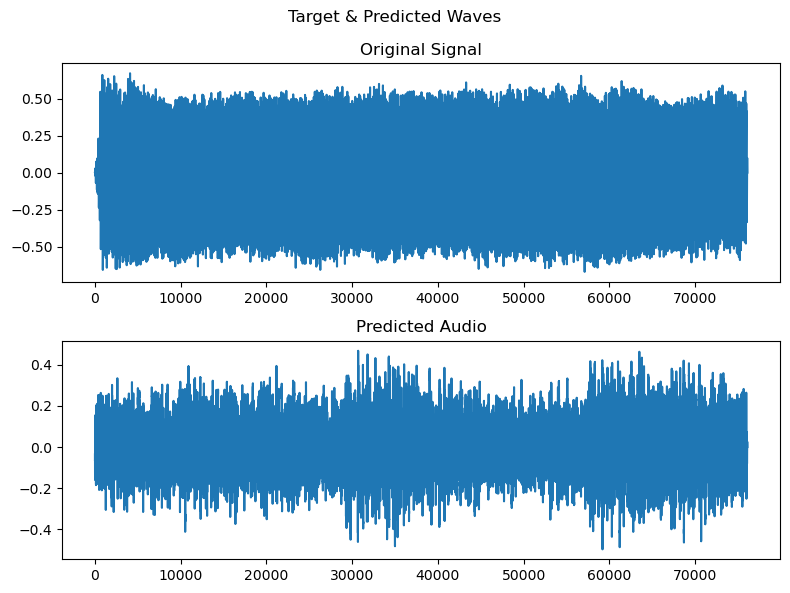

In [68]:
fig, axs = plt.subplots(2, figsize=(8, 6))
fig.suptitle("Target & Predicted Waves")
axs[0].set_title("Original Signal")
axs[0].plot(stitched_wave_target)
axs[1].set_title("Predicted Audio")
axs[1].plot(stitched_wave_prediction)
fig.tight_layout()
plt.show()